# This document serves as guideline for creating plots for a paper

Load functions and packages

In [96]:
library(plotly);
library(tidyverse); # for data manipulation and visualization
library(patchwork); # for combining plots
library(here); # for file path management
library(arrow); # for saving dataframes
library(ptw);
library(pracma);
library(ggforce);
library(purrr);

split_by_species <- function(df, species_col = "species") {
  split(df, df[[species_col]])
}


plot_by_time <- function(df, title_input = "Title") {
  df |> 
    filter(instrument == "DAD") |>
    mutate(sample_id = paste(enzyme, sample, time_point, species, sep = "_")) |>
    ggplot(
      aes(
        x = time,
        y = intensity,
        color = time_point,
        group = sample_id,
    )
  ) +
  geom_line() +
  labs(
    title = title_input,
    x = "Retention Time",
    y = "Intensity (au)"
  )+
  theme(
    plot.title = element_text(face = "bold"), 
    axis.title.x = element_text(face = "bold"),         
    axis.title.y = element_text(face = "bold"))
  
}


wide_to_long <- function(df) {
  df |> 
    pivot_longer(
      cols = where(is.numeric),
      names_to = "time",
      values_to = "intensity"
    )
}

long_to_wide <- function(df) {
  df |>
    pivot_wider(
      id_cols = where(~ !is.numeric(.x)),
      names_from = time,
      values_from = intensity
    )
}


##############-----------------------Scale----------------------------#######################
riemann_integrate <- function(df, rt1, rt2){
  df <- df |>
    mutate(time = as.numeric(time)) |> 
    select(where(is.numeric))
  
  df |>
  filter(time >= rt1, time <= rt2) |>
  arrange(time) |>
  mutate(
    dt = time - lag(time),
    intensity_mid = (intensity + lag(intensity)) / 2,
    area = dt * intensity_mid
  ) |> 
  filter(!is.na(area)) |> 
  summarise(area = sum(area)) |>
  pull(area)
}

normalize <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

normalize_byspecies <- function(df, t_min = .7, t_max = 10, from_wide = FALSE){
  if (from_wide) {
    df <- df |> wide_to_long()
  }

  df |>
    mutate(time = as.numeric(time)) |>
    group_by(species, sample, time_point) |>
    mutate(
      total_area = riemann_integrate(cur_data(), t_min, t_max),
      intensity = intensity / total_area
    ) |>
    ungroup() |>
    select(-total_area)
}

##############-----------------------Baseline-------------------------#######################
correct_baseline <- function(df, l = 1*10^9, maxit = 25, meta_in = TRUE) {
  # keep metadata
  if (meta_in) {
  meta <- df |> select(where(~ !is.numeric(.)))
  }

  # apply baseline correction only to numeric columns
  numeric_df <- df |> select(where(is.numeric))
  numeric_corrected <- baseline.corr(numeric_df, lambda = l, p = 0.001, eps = 1e-8, maxit = maxit)
  
  if (meta_in) {
  combined <- bind_cols(meta, numeric_corrected)
  return(combined)
  }
  return(numeric_corrected)
}
##############------------------------PCA-------------------------#######################
pca <- function(df, num_comp = 10, center_in = TRUE, scale_in = TRUE, scale_na = FALSE) {

  df <- df |> 
    mutate(time_point = factor(time_point, levels = c("0", "2", "5", "15", "30")))
  
  metadata <- df |> 
    select(!where(is.numeric))

  if (scale_na) {
  dataPCA <- df |>
    select(where(is.numeric)) |>
    mutate(across(
      everything(),
      ~ ifelse(is.na(.), min(., na.rm = TRUE) / 2, .)
    ))
  } else {
  dataPCA <- df |>
    select(where(is.numeric))
  }

  pca_res <- prcomp(dataPCA, center = center_in, scale. = scale_in)

  scores <- as.data.frame(pca_res$x[, 1:num_comp, drop = FALSE])
  scores <- bind_cols(metadata, scores)
  loadings <- as.data.frame(pca_res$rotation[, 1:num_comp, drop = FALSE])
  variance <- data.frame(variance = (pca_res$sdev^2) / sum(pca_res$sdev^2))

  list(
    df = df,
    scores = scores,
    loadings = loadings,
    variance = variance
  )
}

plot_scores <- function(scores, PC_first, PC_second, title_in = "", file_path = NULL) {

  PC_first  <- rlang::enquo(PC_first)
  PC_second <- rlang::enquo(PC_second)

  # circle_df <- scores |> 
  #   group_by(species) |> 
  #   summarize(
  #     x0 = mean(!!PC_first, na.rm = TRUE),
  #     y0 = mean(!!PC_second, na.rm = TRUE),
  #     r = max(
  #       sqrt((!!PC_first - x0)^2 + (!!PC_second - y0)^2),
  #       na.rm = TRUE
  #     ),
  #     .groups = "drop"
  #   )

  # label_positions <- circle_df |> 
  #   mutate(
  #     dx = x0 / sqrt(x0^2 + y0^2),
  #     dy = y0 / sqrt(x0^2 + y0^2),
  #     x = x0 + dx * (r * 1.08),
  #     y = y0 + dy * (r * 1.08)
  #   )

  p <- ggplot(scores, aes(x = !!PC_first, y = !!PC_second)) +

    geom_point(
      aes(color = time_point), #, shape = species),
      size = 3
    ) +

    # geom_label(
    #   data = label_positions,
    #   aes(x = x, y = y, label = species),
    #   inherit.aes = FALSE,
    #   fill = "white",
    #   color = "black",
    #   size = 3,
    #   label.size = 0.25
    # ) +

    scale_color_viridis_d(
      option = "viridis",
      name = "Incubation Time"
    ) +

    labs(
      title = title_in,
      subtitle = "Colored by incubation time; species-level dispersion shown",
      x = rlang::as_label(PC_first),
      y = rlang::as_label(PC_second)
    ) +

    coord_equal() +
    theme_minimal()

  if (!missing(file_path) && !is.null(file_path)) {
  ggsave(
    filename = file_path,
    plot = p,
    dpi = 300,
    width = 8,
    height = 6,
    units = "in"
  )
  }
  return(p)
}

plot_loadings <- function(df, PC) {
  PC  <- rlang::enquo(PC)

  ggplot(df, aes(x = time, y = !!PC))+ 
  geom_line()+
  labs(title = "PCA Loadings Plot",
       x = "Time",
       y = rlang::as_label(PC)) +
  theme_minimal()
}

plot_scree <- function(df){
  df <- df |> 
  mutate(
    PC = factor(
      paste0("PC", row_number()),
      levels = paste0("PC", row_number())
    )
  )

  df_new <- df |> 
  mutate(cumulative = cumsum(variance)) |> 
  slice(1:10)
  
  ggplot(df_new, aes(x = PC, y = variance, group = 1)) +
  geom_line(linewidth = .7) +
  geom_point(size = 1) +
  geom_text(data = df_new |> slice(1:4),
            inherit.aes = FALSE,
            aes(x = PC, y = variance, label = paste0(round(cumulative*100), "%")), 
            vjust = -0.5, hjust = -.4, size = 3) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Scree Plot of Principal Components",
    x = "Principal Component",
    y = "Proportion of Variance Explained",
    caption = "Percentages indicate cumulative variance explained"
  ) +
  theme_minimal()
}

##############------------------------PTW-------------------------#######################


ptw_function <- function(df) {
  meta <- df |> 
    select(time_point, species, sample, enzyme, instrument)

  Num <- df |> select(where(is.numeric))

  reference_num <- Num[1, ]
  samples_num   <- Num[2:15, ]

  reference_meta <- meta[1, ]
  samples_meta   <- meta[2:15, ]

  res <- ptw(reference_num, samples_num, warp.type = "individual")

  warped_df <- as.data.frame(res$warped.sample)
  reference_df <- as.data.frame(res$reference)

  colnames(warped_df) <- colnames(reference_df)

  warped_full <- bind_cols(samples_meta, warped_df)
  reference_full <- bind_cols(reference_meta, reference_df)

  final_df <- bind_rows(reference_full, warped_full)

  return(final_df)
}


Load dataframe. This dataframe is baseline corrected and aligned, we normalize. 

We mutate the time point column such that it is a factor type rather than numeric, most functions work by selecting between non-numeric columns and numeric columns.

There are some missing values at the very end of the spectrum.

Also create a wide version as this will be helpful for pca.

In [ ]:
Long_in <- read_csv('../data/processed/fullAligned.csv', show_col_types = FALSE)

Long <- Long_in |> 
  normalize_byspecies() |> 
  mutate(time_point = factor(time_point, levels = c(0,2,5,15,30))) 

Wide <- long_to_wide(Long) 

Now create PCA data frames. We will have the following comparisons for each assay, CYP, UGT and CYP + UGT.
1. All species, all samples
2. Split by species, compare time course

# 1

In [27]:
pre_pca <- Wide |> 
  select(where(~ !any(is.na(.))))

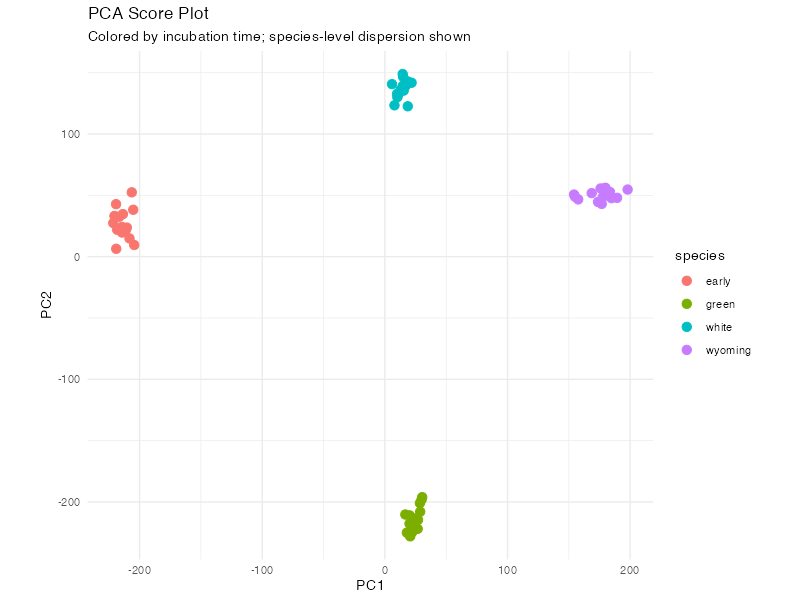

In [ ]:
pca_1_res <- pca(pre_pca)
scores = pca_1_res$scores

p <- ggplot(scores, aes(x = PC1, y = PC2)) +
    geom_point(
      aes(color = species),
      size = 3
    ) +
    labs(
      title = "PCA Score Plot",
      subtitle = "Colored by incubation time; species-level dispersion shown",
      x = 'PC1',
      y = 'PC2'
    ) +
    coord_equal() +
    theme_minimal()

p

ggsave(
    filename = '../images/PCA_allSpecies.png',
    plot = p,
    dpi = 300,
    width = 8,
    height = 6,
    units = "in"
  )

# PCA Within Species Compare Time Course

In order to compare by species create a data frame for each species.

In [98]:
species_df <- split_by_species(Wide)

Green <- species_df[['green']]
White <- species_df[['white']]
Early <- species_df[['early']]
Wyoming <- species_df[['wyoming']]

In [99]:
pre_pca_green <- Green |> 
  select(where(~ !any(is.na(.))))
pca_green_res <- pca(pre_pca_green)
green_scores = pca_green_res$scores

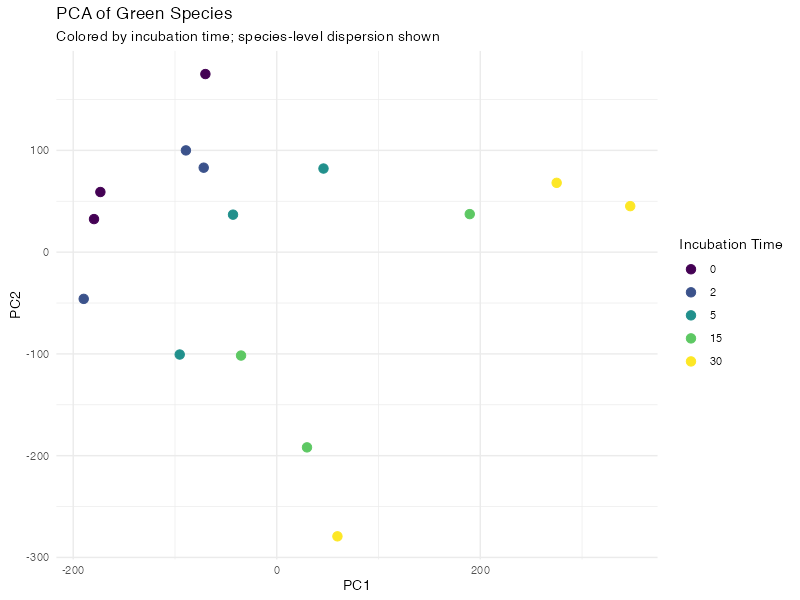

In [100]:
plot_scores(green_scores, PC1, PC2, title_in = "PCA of Green Species", file_path = "../images/pca/green_pca.png")

In [101]:
pre_pca_white <- White |> 
  select(where(~ !any(is.na(.))))
pca_white_res <- pca(pre_pca_white)
white_scores = pca_white_res$scores

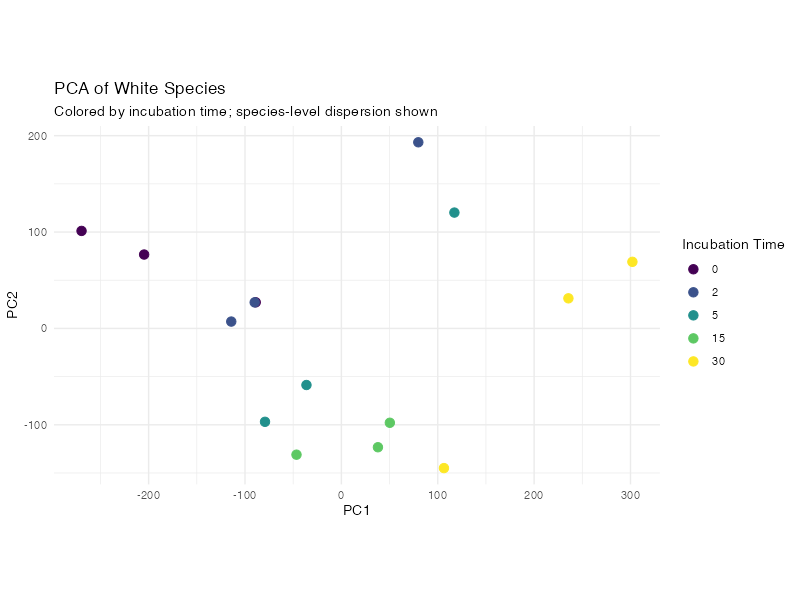

In [102]:
plot_scores(white_scores, PC1, PC2, title_in = "PCA of White Species", file_path = "../images/pca/white_pca.png")

In [103]:
pre_pca_early <- Early |> 
  select(where(~ !any(is.na(.))))
pca_early_res <- pca(pre_pca_early)
early_scores = pca_early_res$scores

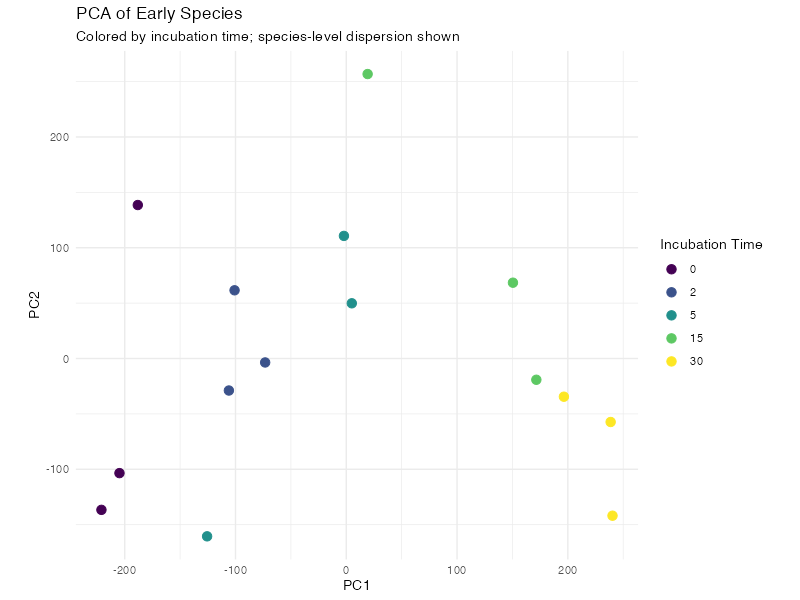

In [104]:
plot_scores(early_scores, PC1, PC2, title_in = "PCA of Early Species", file_path = "../images/pca/early_pca.png")

In [105]:
pre_pca_wyoming <- Wyoming |> 
  select(where(~ !any(is.na(.))))
pca_wyoming_res <- pca(pre_pca_wyoming)
wyoming_scores = pca_wyoming_res$scores
wyoming_loadings = pca_wyoming_res$loadings
wyoming_loadings <- wyoming_loadings |> 
  mutate(time = as.numeric(colnames(pre_pca_wyoming)[sapply(pre_pca_wyoming, is.numeric)])) %>%
  relocate(time)

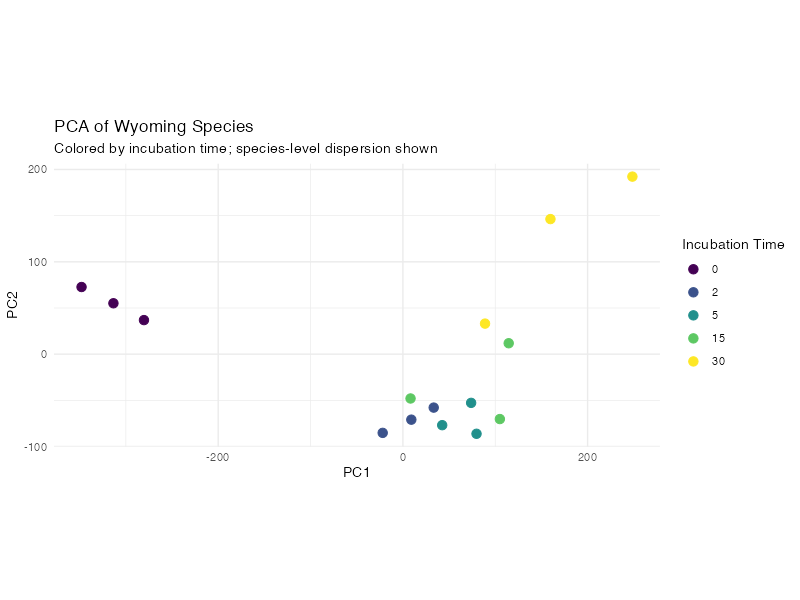

In [106]:
plot_scores(wyoming_scores, PC1, PC2, title_in = "PCA of Wyoming Species", file_path = "../images/pca/wyoming_pca.png")

#plot_loadings(wyoming_loadings, PC1)